In [22]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [25]:
# =====================================
# Salary Prediction Project
# =====================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [26]:
import pandas as pd
import os

# =====================================
# Load Dataset
# =====================================

file_name = "Salary_Data.csv"

# Check if the file exists. If not, prompt the user to place it in the same folder.
if not os.path.exists(file_name):
    print(f"File '{file_name}' not found. Please make sure it's in the same directory as your notebook.")
else:
    print(f"File '{file_name}' found. Proceeding to load.")

# Load the dataset
df = pd.read_csv(file_name)

# Preview the first few rows
print(df.head())


File 'Salary_Data.csv' found. Proceeding to load.
    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


In [27]:
# =====================================
# Basic Information
# =====================================

print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB
None
               Age  Years of Experience         Salary
count  6702.000000          6701.000000    6699.000000
mean     33.620859             8.094687  115326.964771
std       7.614633             6.059003   52786.183911
min      21.000000             0.000000     350.000000
25%      28.000000             3.000000   70000.000000
50%      32.000000             7.000000  115000.000000
75%      38.000000            12.000000  160000.00

In [28]:
# =====================================
# Missing Values
# =====================================

print(df.isnull().sum())

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64


In [29]:
# Drop rows with NaN values in the 'Salary' column
df.dropna(subset=['Salary'], inplace=True)

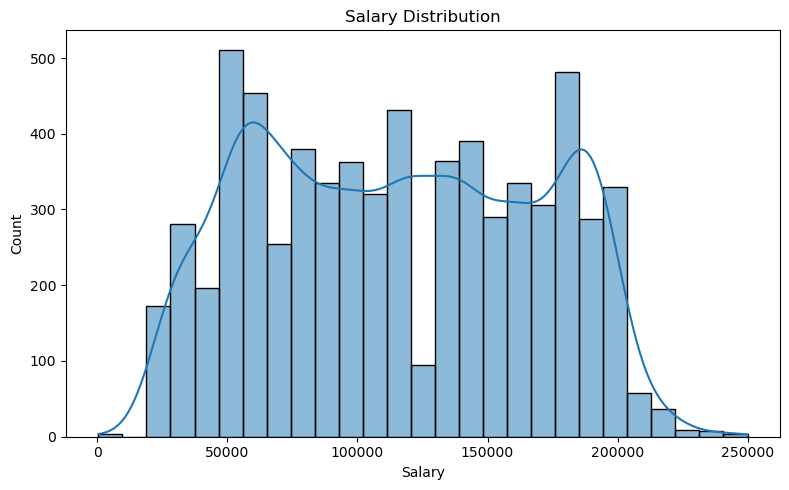

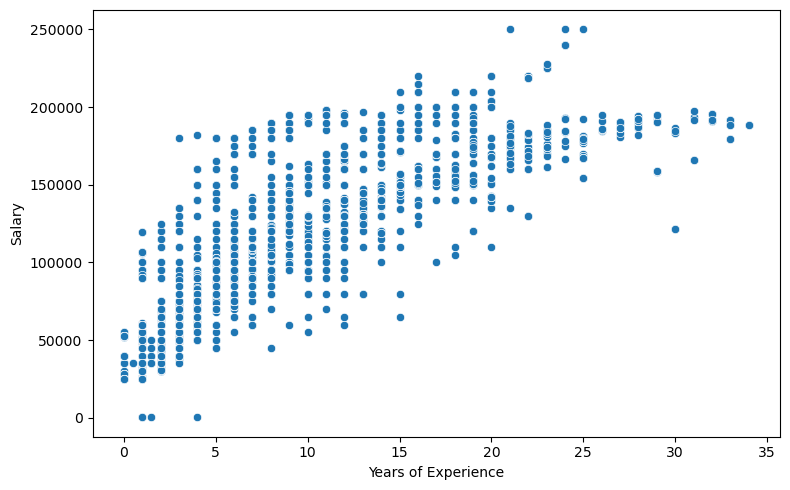

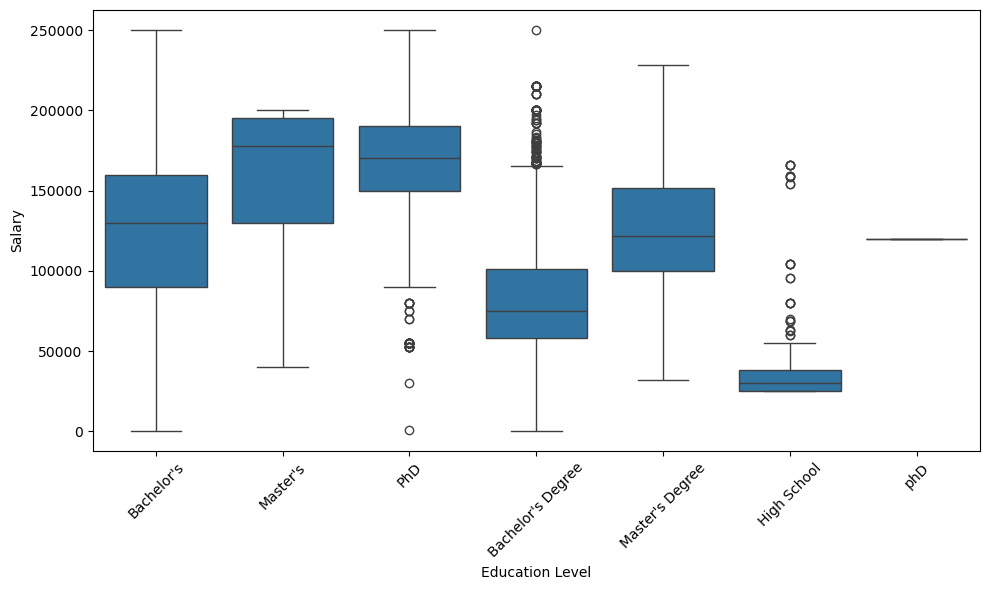

In [30]:
# =====================================
# EDA
# =====================================

plt.figure(figsize=(8,5))
sns.histplot(df["Salary"], kde=True)
plt.title("Salary Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(
    x="Years of Experience",
    y="Salary",
    data=df
)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(
    x="Education Level",
    y="Salary",
    data=df
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
# =====================================
# Features & Target
# =====================================

X = df.drop("Salary", axis=1)
y = df["Salary"]

In [32]:
# =====================================
# Identify Column Types
# =====================================

numeric_features = [
    "Age",
    "Years of Experience"
]

categorical_features = [
    "Gender",
    "Education Level",
    "Job Title"
]

In [33]:
# =====================================
# Numerical Pipeline
# =====================================

numeric_transformer = Pipeline(
    steps=[
        ("imputer",
         SimpleImputer(strategy="median"))
    ]
)

In [34]:
# =====================================
# Categorical Pipeline
# =====================================

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [35]:
# =====================================
# Combine Pipelines
# =====================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


In [36]:
# =====================================
# Train Test Split
# =====================================

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)


In [37]:
# =====================================
# Models
# =====================================

models = {

    "Linear Regression":
        LinearRegression(),

    "Decision Tree":
        DecisionTreeRegressor(
            random_state=42
        ),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=200,
            random_state=42
        ),

    "XGBoost":
        XGBRegressor(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=6,
            random_state=42
        )
}

results = []

best_model = None
best_score = -999

In [38]:
# =====================================
# Train Models
# =====================================

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    predictions = pipeline.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    mse = mean_squared_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append(
        [
            name,
            mae,
            rmse,
            r2
        ]
    )

    if r2 > best_score:
        best_score = r2
        best_model = pipeline

In [39]:
# =====================================
# Results Table
# =====================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
)

print(results_df)

               Model           MAE          RMSE        R2
0  Linear Regression  13135.895490  18598.115664  0.878335
1      Decision Tree   2507.221664   7495.604862  0.980237
2      Random Forest   2612.537450   6527.509972  0.985013
3            XGBoost   5226.866255   7957.097238  0.977729


In [40]:
# Predict on test data
test_predictions = best_model.predict(X_test)

# R2 score
r2 = r2_score(y_test, test_predictions)

# Convert to percentage-like accuracy
accuracy_percent = r2 * 100

print("Model Accuracy (% based on R2):", accuracy_percent)

Model Accuracy (% based on R2): 98.5012658982615


In [41]:
import joblib
# =====================================
# Save Best Model
# =====================================

joblib.dump(
    best_model,
    "best_salary_model.pkl"
)

print("Best model saved!")

Best model saved!


In [42]:
# =====================================
# Prediction Function
# =====================================

def predict_salary(
    age,
    gender,
    education,
    job_title,
    experience
):

    model = joblib.load(
        "best_salary_model.pkl"
    )

    sample = pd.DataFrame({
        "Age":[age],
        "Gender":[gender],
        "Education Level":[education],
        "Job Title":[job_title],
        "Years of Experience":[experience]
    })

    prediction = model.predict(sample)

    return prediction[0]

In [43]:
salary = predict_salary(
    age=30,
    gender="Male",
    education="Master's",
    job_title="Data Scientist",
    experience=5
)

print(
    f"Predicted Salary: {salary}"
)

Predicted Salary: 171785.38835010384


In [44]:
model = joblib.load("best_salary_model.pkl")
# Predict on X_test
test_predictions = model.predict(X_test)

# Create comparison DataFrame
results_test = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": test_predictions
})

print(results_test.head(10))

   Actual Salary  Predicted Salary
0        90249.0      81736.905929
1       135000.0     135000.000000
2        80000.0      79774.501403
3        64182.0      64500.240006
4        40000.0      35107.000000
5       140000.0     144785.703160
6        40000.0      40255.000000
7        90000.0      82925.882656
8       170000.0     170000.000000
9       145000.0     145000.000000


In [46]:
salary = predict_salary(
    age=23,
    gender="Female",
    education="Master's",
    job_title="Sales",
    experience=1
)

print(
    f"Predicted Salary: {salary}"
)

Predicted Salary: 72644.55
